<a href="https://colab.research.google.com/github/CodingWills/Cyber_Jollof/blob/main/Activity2_Manuel_Wills__1251114260_NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 2 – Neural Networks for Regression and Multi-Class Classification
MSc – IS502 | Manuel Wills

This notebook solves Activity 2 in two parts:
- Part A: MLP Regression on California Housing dataset (scikit-learn)
- Part B: CNN Multi-Class Classification on Digits dataset (PyTorch)
- Bonus: Save Best Weights during CNN training

Step 0 - Installing and Importing all the packages & Libraries needed

In [9]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import fetch_california_housing, load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Use GPU if available (Colab provides one)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


PART A - MLP Regression with 3-Fold Cross-Validation & Grid Search

Here, a multi-layer perceptron (MLP), a simple feed-forward neural network is used to predict house prices. This is a regression task because the output is a continuous number

Step A1 - Load the California Housing Dataset

In [10]:
# Load dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Display dataset shape
print('Dataset shape (rows, columns):', X.shape)
print()

# Display feature names
print('Feature names:')
for i, name in enumerate(housing.feature_names):
    print(f'  {i+1}. {name}')
print()

# Summary statistics
df = pd.DataFrame(X, columns=housing.feature_names)
df['Target_HousePrice'] = y
print('Summary statistics:')
print(df.describe().round(2))

Dataset shape (rows, columns): (20640, 8)

Feature names:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

Summary statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  Target_HousePrice  
count  20640.00   20640.00           20640.00  
mean      35.63    -119.57               2.07  
std        2.1

Step A2 - Split Data into Training and Test Sets.

Follwing the process "split before scaling". This is essential to avoid data leakage. Data leakage means the test set influences training, giving perfect or unrealistically good results.

In [11]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 16512
Test samples:     4128


Step A3 - Apply Feature Scaling (Standardization)

MLPs are sensitive to feature scale. If one feature is in thousands and another is 0-1, the network struggles. Standardization makes mean=0 and std=1 for all features.

Rule= Fit scaler ONLY on training data, then transform both sets.

In [12]:
scaler = StandardScaler()

# Fit on training only, then transform
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test set — never fit on it
X_test_scaled = scaler.transform(X_test)

print('Scaling done.')
print(f'Training mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)}')
print(f'Training std  (should be ~1): {X_train_scaled.std(axis=0).round(2)}')

Scaling done.
Training mean (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]
Training std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


Step A4 - Define KFold and GridSearchCV

KFold CV: Instead of one train/val split, we do it 3 times. Each chunk gets to be validated once. This makes the average score is more reliable.

GridSearch: Tries every hyperparameter combination and picks the best one.

In [13]:
# KFold strategy: 3 folds, shuffled
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameter grid — all combinations will be tested
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01],
    'alpha':              [0.0001, 0.001]
}

# Base MLP model
mlp = MLPRegressor(max_iter=500, random_state=42)

# Grid search setup
# neg_mean_squared_error: picks combo with lowest MSE
# n_jobs=-1: use all CPU cores
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

total_combos = 3 * 2 * 2 * 2 * 2
print(f'Grid search ready. Total combinations to test: {total_combos}')

Grid search ready. Total combinations to test: 48


Step A5 - Run the Grid Search

In [14]:
# Run grid search on scaled training data
grid_search.fit(X_train_scaled, y_train)

print('\n--- Grid Search Results ---')
print('Best hyperparameters:')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')

best_cv_mse = -grid_search.best_score_
print(f'\nBest CV MSE:  {best_cv_mse:.4f}')
print(f'Best CV RMSE: {np.sqrt(best_cv_mse):.4f}')

Fitting 3 folds for each of 48 candidates, totalling 144 fits

--- Grid Search Results ---
Best hyperparameters:
  activation: tanh
  alpha: 0.0001
  hidden_layer_sizes: (64, 32)
  learning_rate_init: 0.001
  solver: adam

Best CV MSE:  0.2725
Best CV RMSE: 0.5220


Step A6 - Retain Best Model on Full Training Set

Note: GridSearch found the best parameters using 2/3 of training data at a time. Now we retain with ALL training data using those parameters.

In [15]:
best_params = grid_search.best_params_

best_mlp = MLPRegressor(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    solver=best_params['solver'],
    learning_rate_init=best_params['learning_rate_init'],
    alpha=best_params['alpha'],
    max_iter=500,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)
print('Best model retrained on full training set.')

Best model retrained on full training set.


Step A7 - Evaluate on Test Set

In [16]:
y_pred = best_mlp.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('--- Final Model Test Set Evaluation ---')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')
print(f'\nThe model explains {r2*100:.1f}% of the variance in house prices.')

--- Final Model Test Set Evaluation ---
MSE:  0.2647
RMSE: 0.5145
MAE:  0.3450
R2:   0.7980

The model explains 79.8% of the variance in house prices.


Step 8 - Plots: Predicted Vs Actual Training Loss Curve

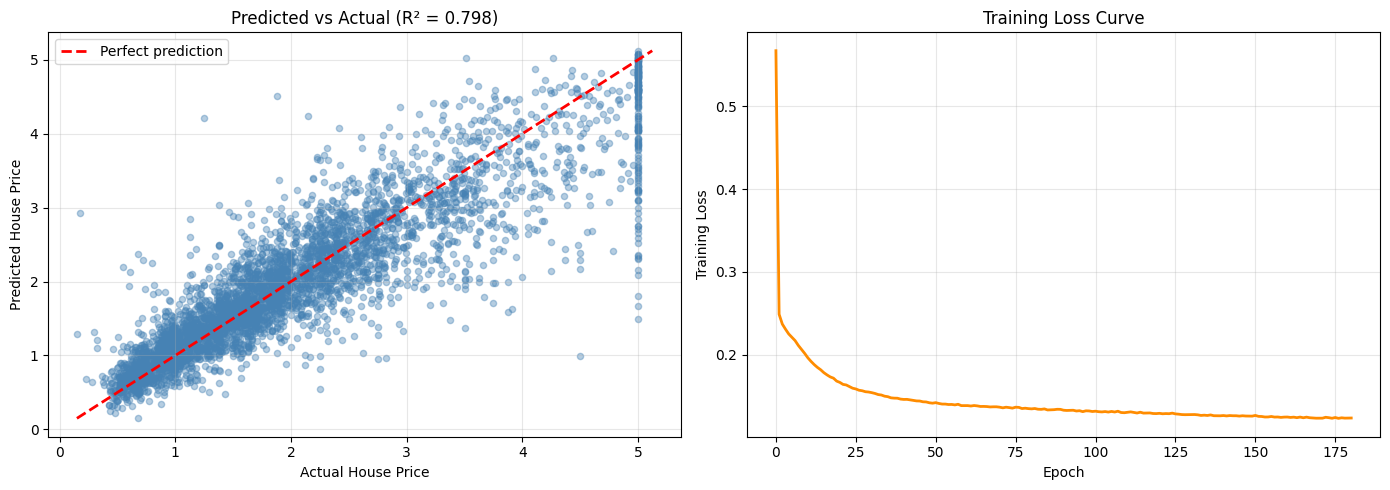

Plots saved as partA_plots.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual House Price')
axes[0].set_ylabel('Predicted House Price')
axes[0].set_title(f'Predicted vs Actual (R² = {r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Training Loss Curve
axes[1].plot(best_mlp.loss_curve_, color='darkorange', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Curve')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('partA_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved as partA_plots.png')

PART B - CNN Multi-Class Classification with PyTorch

Here, we build a CNN to recognise handwritten digits (0-9). This is a 10 class classification task. CNN works well for images because they learn spatial patterns like edges and curves.

Step B1 - Load the Digital Dataset

Dataset shape: (1797, 64)
Number of classes: 10
Samples per class: [178 182 177 183 181 182 181 179 174 180]


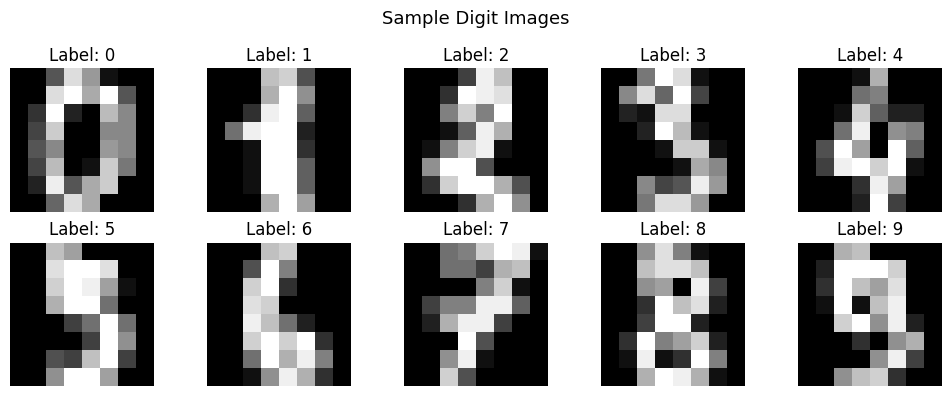

In [18]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print('Dataset shape:', X_digits.shape)
print('Number of classes:', len(np.unique(y_digits)))
print('Samples per class:', np.bincount(y_digits))

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.suptitle('Sample Digit Images', fontsize=13)
plt.tight_layout()
plt.savefig('partB_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Step B2 - Normalize & Reshape Images

Pixel values are 0-16. We normalize to 0-1. CNN need shape (samples, channels, height, width) = (N, 1, 8, 8).

In [19]:
# Normalize pixels to 0-1
X_norm = X_digits / 16.0

# Reshape: (1797, 64) -> (1797, 1, 8, 8)
X_reshaped = X_norm.reshape(-1, 1, 8, 8)

print('Shape after reshape:', X_reshaped.shape)
print('Value range: min =', X_reshaped.min(), ', max =', X_reshaped.max())

Shape after reshape: (1797, 1, 8, 8)
Value range: min = 0.0 , max = 1.0


Step B3 - Split into Training, Validation, and Test Sets

Three sets:

*   Training (70%): model learns from this
*   Validation (15%): monitor during training to detect overfitting
*  Test (15%): final evaluation only





In [20]:
# First: separate test set (15%)
X_temp, X_test_cnn, y_temp, y_test_cnn = train_test_split(
    X_reshaped, y_digits, test_size=0.15, random_state=42, stratify=y_digits
)

# Then: separate validation from remaining (~17.6% of remaining = 15% of total)
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f'Training:   {X_train_cnn.shape[0]} samples')
print(f'Validation: {X_val_cnn.shape[0]} samples')
print(f'Test:       {X_test_cnn.shape[0]} samples')

Training:   1258 samples
Validation: 269 samples
Test:       270 samples


Step B4 - Convert to PyTorch Tensors

PyTorch works with Tensors, not NumPy arrays. CrossEntropyLoss requires LongTensor for labels.

In [21]:
def make_tensors(X, y):
    return torch.FloatTensor(X), torch.LongTensor(y)

X_train_t, y_train_t = make_tensors(X_train_cnn, y_train_cnn)
X_val_t,   y_val_t   = make_tensors(X_val_cnn,   y_val_cnn)
X_test_t,  y_test_t  = make_tensors(X_test_cnn,  y_test_cnn)

print('Tensors created.')
print('Train:', X_train_t.shape)
print('Val:  ', X_val_t.shape)
print('Test: ', X_test_t.shape)

Tensors created.
Train: torch.Size([1258, 1, 8, 8])
Val:   torch.Size([269, 1, 8, 8])
Test:  torch.Size([270, 1, 8, 8])


Step B5 - Build CNN Architeture

The CNN comprises of:


1.   Convolutional layer: Detects patterns (edges, curves)
2.   Activation function: Adds non-linearity (ReLU or Tann)

3.   Pooling layer: Reduces sizes, keeps key features.
4.   Fully connected layers: combines features for classification.
5. Output layer: 10 neurons, one per digit class





In [22]:
class DigitCNN(nn.Module):
    """
    CNN for classifying 8x8 grayscale digit images.
    num_filters: how many patterns the conv layer detects (16 or 32)
    activation:  'relu' or 'tanh'
    """
    def __init__(self, num_filters=16, activation='relu'):
        super(DigitCNN, self).__init__()

        # Choose activation function
        self.act = nn.ReLU() if activation == 'relu' else nn.Tanh()

        # Convolutional layer
        # in_channels=1: grayscale image
        # out_channels=num_filters: number of patterns to learn
        # kernel_size=3: each filter scans a 3x3 region
        # padding=1: keeps output same size as input (8x8)
        self.conv1 = nn.Conv2d(1, num_filters, kernel_size=3, padding=1)

        # Max pooling: reduces 8x8 to 4x4
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # After conv+pool: num_filters * 4 * 4 features
        self.fc1 = nn.Linear(num_filters * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)  # 10 output classes

    def forward(self, x):
        x = self.pool(self.act(self.conv1(x)))  # Conv -> Act -> Pool
        x = x.view(x.size(0), -1)               # Flatten
        x = self.act(self.fc1(x))               # FC1 -> Act
        x = self.fc2(x)                         # Output (no activation)
        return x


# Quick architecture test
test_model  = DigitCNN(num_filters=16, activation='relu')
test_input  = torch.randn(4, 1, 8, 8)
test_output = test_model(test_input)
print('Architecture test passed.')
print(f'Input:  {test_input.shape}')
print(f'Output: {test_output.shape}  (4 samples, 10 class scores)')
print()
print(test_model)

Architecture test passed.
Input:  torch.Size([4, 1, 8, 8])
Output: torch.Size([4, 10])  (4 samples, 10 class scores)

DigitCNN(
  (act): ReLU()
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


Step B6 - Training Function

A reuseable function that trains the CNN and tracks loss and accuracy per epoch

In [23]:
def train_cnn(config, epochs=30, save_best=False):
    """
    Train a CNN with the given config.
    config keys: num_filters, activation, optimizer_name, lr, batch_size
    save_best: if True, saves weights from epoch with lowest val loss (Bonus)
    Returns: trained model, history dict
    """
    # DataLoaders
    train_ds     = TensorDataset(X_train_t, y_train_t)
    val_ds       = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=config['batch_size'], shuffle=False)

    # Build model
    model = DigitCNN(num_filters=config['num_filters'],
                     activation=config['activation']).to(device)

    # Loss function: CrossEntropyLoss for multi-class
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    if config['optimizer_name'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(epochs):

        # --- Training phase ---
        model.train()
        t_loss, correct, total = 0.0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss  += loss.item() * Xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
        avg_tl = t_loss / total
        avg_ta = correct / total

        # --- Validation phase ---
        model.eval()
        v_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out     = model(Xb)
                loss    = criterion(out, yb)
                v_loss += loss.item() * Xb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        avg_vl = v_loss / total
        avg_va = correct / total

        history['train_loss'].append(avg_tl)
        history['val_loss'].append(avg_vl)
        history['train_acc'].append(avg_ta)
        history['val_acc'].append(avg_va)

        # BONUS: save best weights
        if save_best and avg_vl < best_val_loss:
            best_val_loss = avg_vl
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_tl:.4f} | '
                  f'Val Loss: {avg_vl:.4f} | Val Acc: {avg_va:.3f}')

    if save_best and best_weights:
        model.load_state_dict(best_weights)
        print(f'Best weights restored (val loss: {best_val_loss:.4f})')

    return model, history


print('Training function ready.')

Training function ready.


Step B7 - Defining and Training 4 Hyperparameter Configurations

We test 4 different configurations covering all required hyperparameters.

In [24]:
configs = [
    {'name': 'Config 1 – ReLU, Adam, lr=0.001, filters=16, batch=32',
     'activation': 'relu', 'optimizer_name': 'adam',
     'lr': 0.001, 'num_filters': 16, 'batch_size': 32},

    {'name': 'Config 2 – ReLU, Adam, lr=0.001, filters=32, batch=64',
     'activation': 'relu', 'optimizer_name': 'adam',
     'lr': 0.001, 'num_filters': 32, 'batch_size': 64},

    {'name': 'Config 3 – Tanh, SGD, lr=0.001, filters=16, batch=32',
     'activation': 'tanh', 'optimizer_name': 'sgd',
     'lr': 0.001, 'num_filters': 16, 'batch_size': 32},

    {'name': 'Config 4 – ReLU, SGD, lr=0.0005, filters=32, batch=64',
     'activation': 'relu', 'optimizer_name': 'sgd',
     'lr': 0.0005, 'num_filters': 32, 'batch_size': 64}
]

EPOCHS = 30
all_models    = []
all_histories = []

for config in configs:
    print(f'\n===== {config["name"]} =====')
    model, history = train_cnn(config, epochs=EPOCHS, save_best=False)
    all_models.append(model)
    all_histories.append(history)
    print(f'Final Val Accuracy: {history["val_acc"][-1]:.4f}')


===== Config 1 – ReLU, Adam, lr=0.001, filters=16, batch=32 =====
Epoch  5/30 | Train Loss: 0.4160 | Val Loss: 0.4253 | Val Acc: 0.881
Epoch 10/30 | Train Loss: 0.1720 | Val Loss: 0.2416 | Val Acc: 0.911
Epoch 15/30 | Train Loss: 0.1038 | Val Loss: 0.1813 | Val Acc: 0.941
Epoch 20/30 | Train Loss: 0.0662 | Val Loss: 0.1528 | Val Acc: 0.944
Epoch 25/30 | Train Loss: 0.0523 | Val Loss: 0.1342 | Val Acc: 0.944
Epoch 30/30 | Train Loss: 0.0390 | Val Loss: 0.1216 | Val Acc: 0.955
Final Val Accuracy: 0.9554

===== Config 2 – ReLU, Adam, lr=0.001, filters=32, batch=64 =====
Epoch  5/30 | Train Loss: 0.6487 | Val Loss: 0.6044 | Val Acc: 0.874
Epoch 10/30 | Train Loss: 0.2155 | Val Loss: 0.2711 | Val Acc: 0.907
Epoch 15/30 | Train Loss: 0.1277 | Val Loss: 0.1957 | Val Acc: 0.933
Epoch 20/30 | Train Loss: 0.0856 | Val Loss: 0.1618 | Val Acc: 0.955
Epoch 25/30 | Train Loss: 0.0667 | Val Loss: 0.1323 | Val Acc: 0.955
Epoch 30/30 | Train Loss: 0.0457 | Val Loss: 0.1349 | Val Acc: 0.944
Final Val A

Step B8 - Results Comparison Table

In [25]:
results = []
for i, (config, history) in enumerate(zip(configs, all_histories)):
    results.append({
        'Config':         f'Config {i+1}',
        'Activation':     config['activation'],
        'Optimizer':      config['optimizer_name'],
        'LR':             config['lr'],
        'Filters':        config['num_filters'],
        'Batch Size':     config['batch_size'],
        'Final Val Loss': round(history['val_loss'][-1], 4),
        'Final Val Acc':  round(history['val_acc'][-1],  4)
    })

results_df = pd.DataFrame(results)
print('--- Hyperparameter Comparison ---')
print(results_df.to_string(index=False))

best_idx = results_df['Final Val Acc'].idxmax()
print(f'\nBest: Config {best_idx+1} with Val Accuracy = {results_df.loc[best_idx, "Final Val Acc"]}')

--- Hyperparameter Comparison ---
  Config Activation Optimizer     LR  Filters  Batch Size  Final Val Loss  Final Val Acc
Config 1       relu      adam 0.0010       16          32          0.1216         0.9554
Config 2       relu      adam 0.0010       32          64          0.1349         0.9442
Config 3       tanh       sgd 0.0010       16          32          0.7861         0.8587
Config 4       relu       sgd 0.0005       32          64          2.1435         0.7100

Best: Config 1 with Val Accuracy = 0.9554


Step B9 - Plot Loss and Accuracy Curves for All Configurations

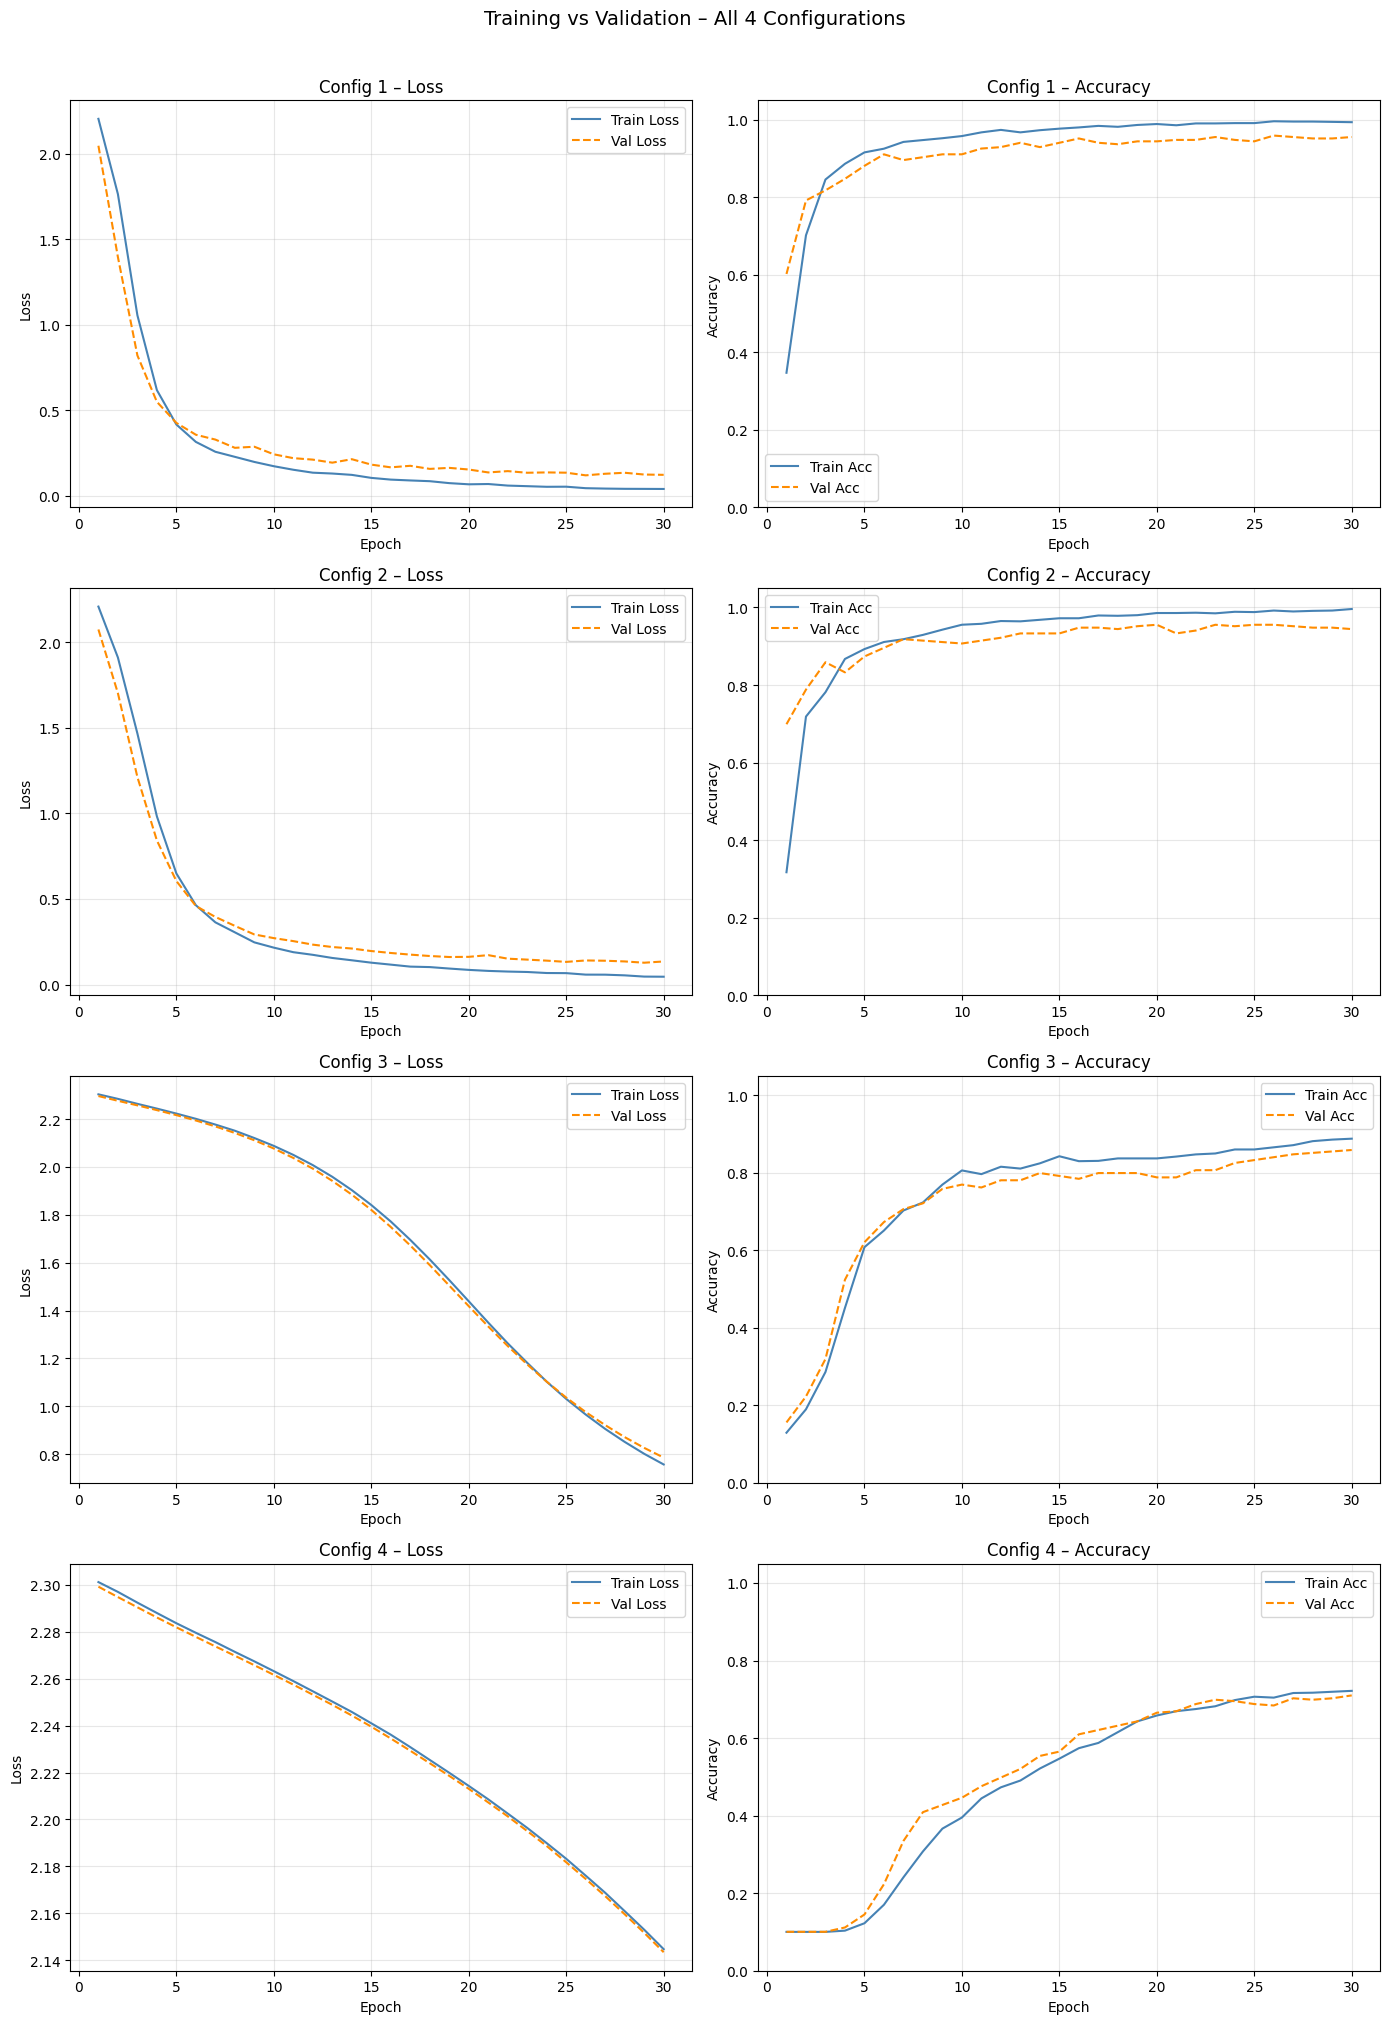

In [26]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
ep = range(1, EPOCHS + 1)

for i, (config, history) in enumerate(zip(configs, all_histories)):
    lbl = f'Config {i+1}'

    # Loss
    axes[i,0].plot(ep, history['train_loss'], label='Train Loss', color='steelblue')
    axes[i,0].plot(ep, history['val_loss'],   label='Val Loss',   color='darkorange', ls='--')
    axes[i,0].set_title(f'{lbl} – Loss')
    axes[i,0].set_xlabel('Epoch'); axes[i,0].set_ylabel('Loss')
    axes[i,0].legend(); axes[i,0].grid(True, alpha=0.3)

    # Accuracy
    axes[i,1].plot(ep, history['train_acc'], label='Train Acc', color='steelblue')
    axes[i,1].plot(ep, history['val_acc'],   label='Val Acc',   color='darkorange', ls='--')
    axes[i,1].set_title(f'{lbl} – Accuracy')
    axes[i,1].set_xlabel('Epoch'); axes[i,1].set_ylabel('Accuracy')
    axes[i,1].set_ylim([0, 1.05])
    axes[i,1].legend(); axes[i,1].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation – All 4 Configurations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('partB_all_configs.png', dpi=150, bbox_inches='tight')
plt.show()

Step B10 - Evaluate Best Configuration on Test Set

In [27]:
best_model = all_models[best_idx]
best_model.eval()

with torch.no_grad():
    outputs    = best_model(X_test_t.to(device))
    y_pred_cnn = outputs.argmax(dim=1).cpu().numpy()
    y_true_cnn = y_test_t.numpy()

acc  = accuracy_score(y_true_cnn, y_pred_cnn)
prec = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
rec  = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
f1   = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print('--- Test Set Evaluation (Best Config) ---')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_true_cnn, y_pred_cnn))

--- Test Set Evaluation (Best Config) ---
Accuracy:  0.9667
Precision: 0.9676
Recall:    0.9667
F1-Score:  0.9659

Full Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.89      0.89      0.89        27
           2       0.96      1.00      0.98        27
           3       1.00      1.00      1.00        28
           4       0.96      0.96      0.96        27
           5       1.00      1.00      1.00        27
           6       0.96      1.00      0.98        27
           7       0.93      1.00      0.96        27
           8       1.00      0.81      0.89        26
           9       0.96      1.00      0.98        27

    accuracy                           0.97       270
   macro avg       0.97      0.97      0.97       270
weighted avg       0.97      0.97      0.97       270



Step B11 - Confusion Matrix

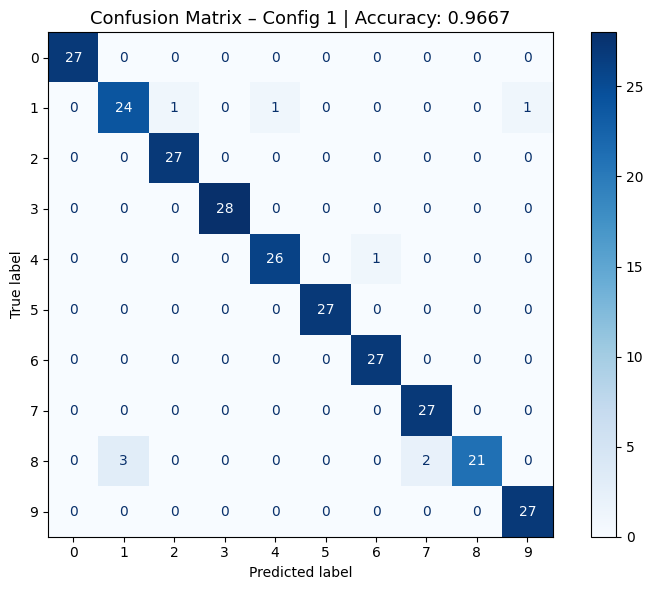

In [28]:
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix – Config {best_idx+1} | Accuracy: {acc:.4f}', fontsize=13)
plt.tight_layout()
plt.savefig('partB_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

BONUS - Save Best Weights Technique

We retain the best configuration, saving weights whenever validation loss improves. At the end we restore the best weights before evaluating.

In [29]:
best_config = configs[best_idx]
print(f'Retraining: {best_config["name"]}')
print('Save Best Weights: ENABLED\n')

best_model_bonus, bonus_history = train_cnn(
    best_config, epochs=EPOCHS, save_best=True
)

Retraining: Config 1 – ReLU, Adam, lr=0.001, filters=16, batch=32
Save Best Weights: ENABLED

Epoch  5/30 | Train Loss: 0.3433 | Val Loss: 0.3355 | Val Acc: 0.922
Epoch 10/30 | Train Loss: 0.1441 | Val Loss: 0.1770 | Val Acc: 0.941
Epoch 15/30 | Train Loss: 0.0929 | Val Loss: 0.1593 | Val Acc: 0.948
Epoch 20/30 | Train Loss: 0.0674 | Val Loss: 0.1319 | Val Acc: 0.955
Epoch 25/30 | Train Loss: 0.0459 | Val Loss: 0.1381 | Val Acc: 0.952
Epoch 30/30 | Train Loss: 0.0378 | Val Loss: 0.1164 | Val Acc: 0.963
Best weights restored (val loss: 0.1039)


--- Bonus Model Test Evaluation (Best Weights Restored) ---
Accuracy: 0.9778
F1-Score: 0.9774


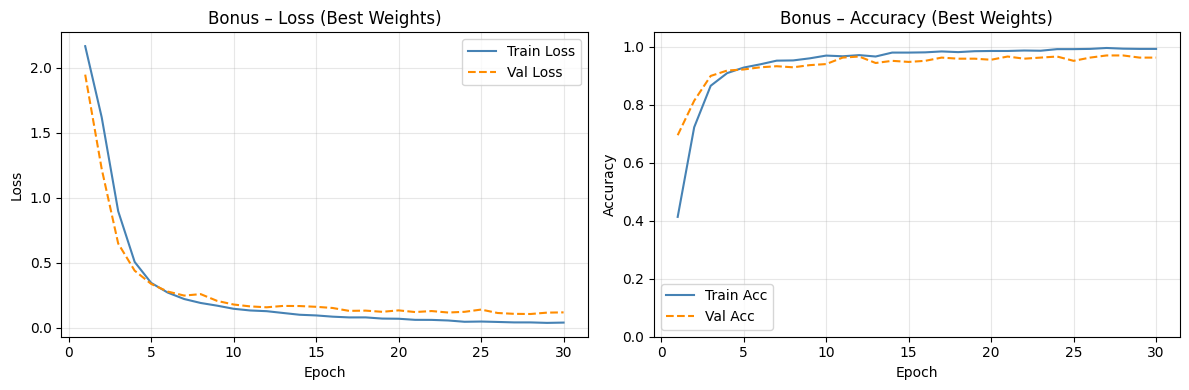

In [30]:
# Evaluate bonus model on test set
best_model_bonus.eval()
with torch.no_grad():
    out_bonus  = best_model_bonus(X_test_t.to(device))
    y_pred_bon = out_bonus.argmax(1).cpu().numpy()

acc_bonus = accuracy_score(y_true_cnn, y_pred_bon)
f1_bonus  = f1_score(y_true_cnn, y_pred_bon, average='weighted')

print('--- Bonus Model Test Evaluation (Best Weights Restored) ---')
print(f'Accuracy: {acc_bonus:.4f}')
print(f'F1-Score: {f1_bonus:.4f}')

# Plot bonus model curves
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, bonus_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(ep, bonus_history['val_loss'],   label='Val Loss',   color='darkorange', ls='--')
axes[0].set_title('Bonus – Loss (Best Weights)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, bonus_history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(ep, bonus_history['val_acc'],   label='Val Acc',   color='darkorange', ls='--')
axes[1].set_title('Bonus – Accuracy (Best Weights)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bonus_plots.png', dpi=150, bbox_inches='tight')
plt.show()